loss: 0.4599003791809082 epoch: 0
loss: 0.00475815637037158 epoch: 500
loss: 0.0007978057255968451 epoch: 1000
loss: 0.00038184356526471674 epoch: 1500
loss: 0.0002806129341479391 epoch: 2000
loss: 0.00018194474978372455 epoch: 2500
loss: 0.00014074050704948604 epoch: 3000
loss: 0.0001361700560664758 epoch: 3500
loss: 9.371322812512517e-05 epoch: 4000
loss: 8.329240517923608e-05 epoch: 4500
Mean abs Error: 0.043833
final loss: 0.002093
torch.Size([500, 500]) torch.Size([500, 500]) torch.Size([250000, 1])


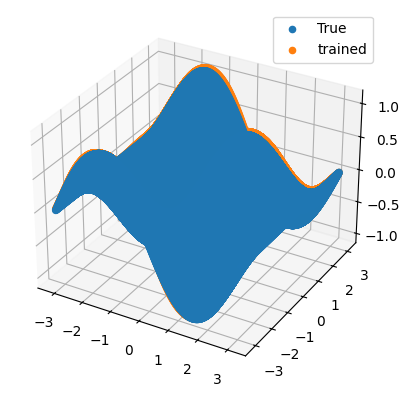

In [1]:
#2-D Input Problem

import torch
import torch.nn as nn
import torch.optim as optim
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

x=torch.linspace(-torch.pi,torch.pi,500)
y=torch.linspace(-torch.pi,torch.pi,500)
X,Y=torch.meshgrid(x,y,indexing='ij')

z=torch.flatten(torch.sin(X)*torch.cos(Y)).view(-1,1)
xy=torch.stack([X.flatten(),Y.flatten()],dim=1)

class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.input=nn.Linear(2,8)
    self.l1=nn.Linear(8,8)
    self.l2=nn.Linear(8,8)
    self.output=nn.Linear(8,1)

  def forward(self,xy):
    xy=torch.tanh(self.input(xy))
    xy=torch.tanh(self.l1(xy))
    xy=torch.tanh(self.l2(xy))
    xy=self.output(xy)

    return xy

model=Net()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

for epoch in range(5000):
  optimizer.zero_grad()
  zpred=model(xy)
  loss=criterion(zpred,z)
  loss.backward()
  optimizer.step()

  if epoch%500==0:
      print('loss:',loss.item(),'epoch:',epoch)

with torch.no_grad():
  pred=model(xy)
  mae=torch.mean(torch.abs(pred-z)).mean()
  print(f"Mean abs Error: {mae.item():0.6f}")
  print(f'final loss: {loss.item():.6f}')

print(X.shape,Y.shape,z.shape)

z=z.reshape(500,500)
pred=pred.reshape(500,500)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X, Y, z, label='True')
ax.scatter(X, Y, pred, label='trained')
ax.legend()
ax.grid(True)

plt.show()


Observation:

1. 2D input means changing input dimension, not output dimension
2. More dimensions = more data needed to cover the domain
3. Surface fitting is harder than curve fitting — more structure to learn
4. Peaks are hard:
high sensitivity + sparse data at the peak
5. Oscillating loss often traces back to the model fighting sharp features